In [1]:
import os
import glob
import gc
import random

from pathlib import Path

import numpy as np
import pandas as pd
import h5py

from scipy.sparse import csr_matrix
from pathlib import Path

import scipy

from scipy.stats import median_abs_deviation, percentileofscore

import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import seaborn as sns

import anndata as ad
import scanpy.external as sce
import scanpy as sc

from cellbender.remove_background.downstream import anndata_from_h5

from tqdm import tqdm

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

In [2]:
SHIN_CELLBENDER_OUTPUTS = glob.glob('/mnt/lacie/scz_meta_analysis/cellbender/shin_nowakowski/*/*output.h5')

In [3]:
# Load all AnnData objects
ad_list = [anndata_from_h5(fp) for fp in SHIN_CELLBENDER_OUTPUTS]
srr_list = [fp.split('/')[-1].split('_')[0] for fp in SHIN_CELLBENDER_OUTPUTS]

# Prep Individual Libraries
for adata, srr in zip(ad_list, srr_list):
    # Prepend SRR ID to cell barcodes
    adata.obs_names = [f"{srr}_{obs}" for obs in adata.obs_names]
    # Set gene_names to unique ENSEMBLE names
    adata.var['gene_name'] = adata.var_names
    adata.var_names = adata.var['gene_id']

# Concatenate
shin_adata = sc.concat(ad_list, join='outer', label='library', keys=srr_list)

/home/deepak/pixi_envs/cellbender/.pixi/envs/default/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/deepak/pixi_envs/cellbender/.pixi/envs/default/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/deepak/pixi_envs/cellbender/.pixi/envs/default/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/deepak/pixi_envs/cellbender/.pixi/envs/default/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(
/home/deepak/pixi_envs/cellbender/.pixi/envs/default/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is depreca

In [4]:
shin_adata.obs['nUMIs'] = shin_adata.X.sum(axis=1)

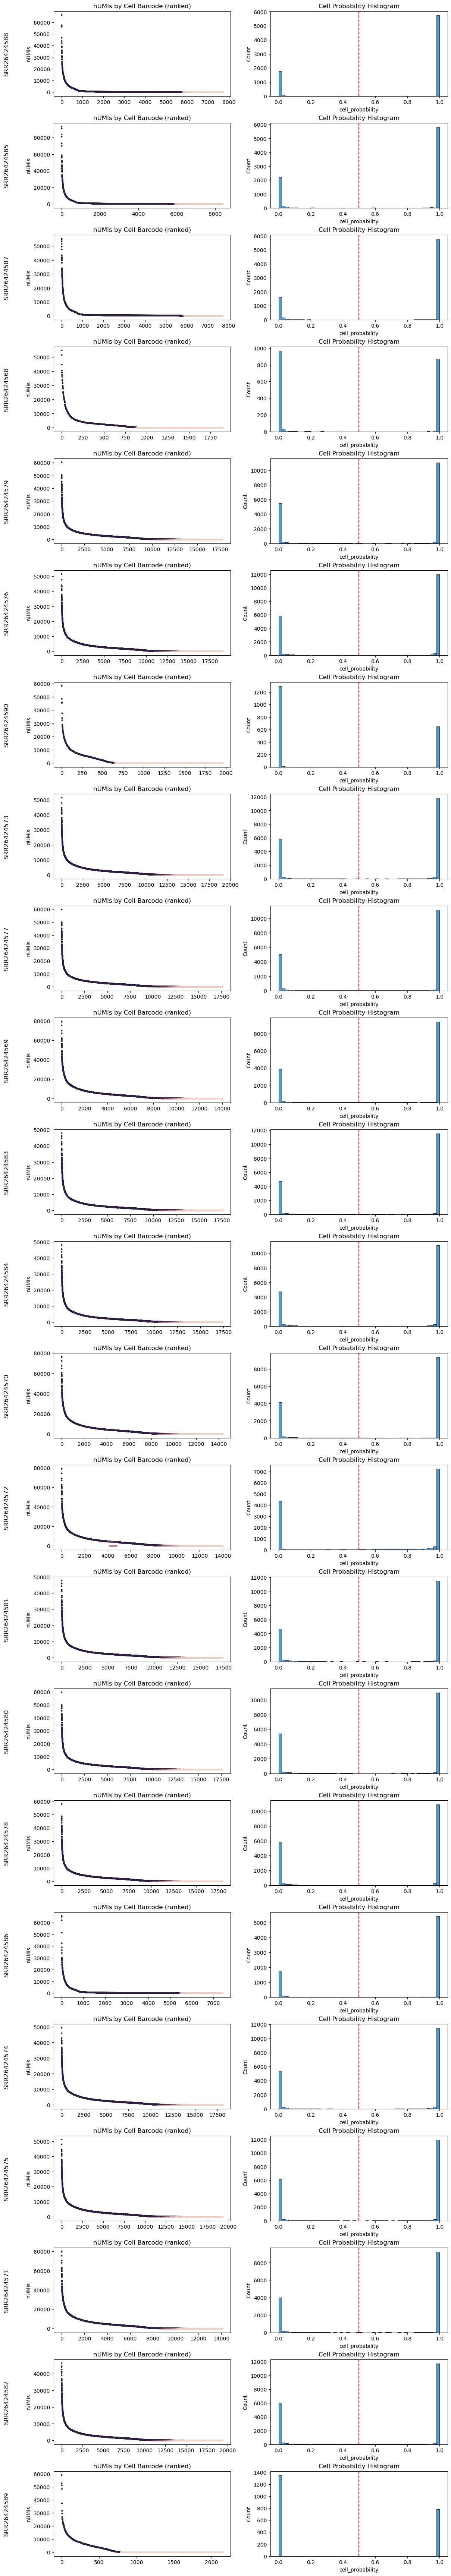

In [5]:
n = len(srr_list)

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(12, 3 * n),   # <-- scale height per SRR
    constrained_layout=True
)

for i, srr in enumerate(srr_list):
    cb_table = shin_adata.obs[shin_adata.obs['library'] == srr]

    # Scatter plot
    sns.scatterplot(
        data=cb_table,
        x=range(cb_table.shape[0]),
        y='nUMIs',
        hue='cell_probability',
        ax=axes[i, 0],
        s=10,
        linewidth=0
    )
    axes[i, 0].set_title('nUMIs by Cell Barcode (ranked)')
    axes[i, 0].set_xlabel('')
    axes[i, 0].legend_.remove()

    # Histogram
    sns.histplot(
        data=cb_table,
        x='cell_probability',
        ax=axes[i, 1],
        bins=50
    )
    axes[i, 1].axvline(0.5, color='red', linestyle='--')
    axes[i, 1].set_title('Cell Probability Histogram')

    # Left-side SRR label (per row)
    axes[i, 0].annotate(
        srr,
        xy=(-0.25, 0.5),
        xycoords='axes fraction',
        va='center',
        ha='right',
        fontsize=12,
        rotation=90
    )

plt.show()

In [6]:
shin_adata.obs['cell'] = (shin_adata.obs['cell_probability'] > 0.5)

In [14]:
[i.split('_')[1] for i in shin_adata.obs_names[shin_adata.obs['cell']]]

['GACGTTACAAGTACCT',
 'TGATTTCGTTGTGGAG',
 'TACTTGTAGCGTTCCG',
 'GCGAGAAAGCGCCTCA',
 'TGAGCATCATGGAATA',
 'TTGCGTCCAACTGCTA',
 'AGCGTCGCAGAGTGTG',
 'CTGGTCTAGGTGGGTT',
 'CATGCCTTCCGTCAAA',
 'CTCATTATCACGACTA',
 'GGTGAAGTCACCTTAT',
 'TTTCCTCGTCCGAAGA',
 'TCGGGACGTATCGCAT',
 'TCGTAGACAGCAGTTT',
 'CTGCCTATCACTCTTA',
 'ACTGATGAGCACACAG',
 'GTCGTAACATAGAAAC',
 'GGGATGAGTTCCACAA',
 'TACTTGTCAAAGCAAT',
 'ACTATCTCAGGCGATA',
 'TTTCCTCAGTGCCAGA',
 'CTCTGGTTCAGTGTTG',
 'ATGAGGGTCCTCTAGC',
 'GTTCATTCACTGTGTA',
 'CGATCGGCAGCATACT',
 'TTAGGCACAGATCCAT',
 'CGTTCTGTCCACGTGG',
 'ATCCACCCACGGTGTC',
 'CGTGTCTAGAGTGACC',
 'CGATGGCTCGCACTCT',
 'CGTTAGACACAGTCGC',
 'CATCCACCAGGGAGAG',
 'GGTGTTAAGCAGGCTA',
 'GCAGTTATCTTACCGC',
 'CAACCAAGTAGATTAG',
 'TTTATGCCACACAGAG',
 'TCGTAGATCTGCCCTA',
 'GTCAAGTGTTGGGACA',
 'GGATGTTCAAGCCATT',
 'GACGTTAGTTTGTTGG',
 'CTTAGGACAAGCCATT',
 'GGACGTCGTCGAACAG',
 'CATGCCTGTTGGACCC',
 'TGATTTCGTACGAAAT',
 'TTTGGTTCAAGAGGCT',
 'TCATTTGCACGGCCAT',
 'TTCGGTCGTTACGGAG',
 'GATGAGGAGTC

In [16]:
float(shin_adata.obs['cell'].sum()) / shin_adata.shape[0]

0.6610151568558337

In [38]:
srr_list[0:5]

['SRR26424588', 'SRR26424585', 'SRR26424587', 'SRR26424568', 'SRR26424579']

In [39]:
glob.glob('/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/star_outputs/*')

['/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/star_outputs/SRR26424570_Log.final.out',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/star_outputs/SRR26424571_Aligned.sortedByCoord.out.bam.bai',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/star_outputs/SRR26424586_Aligned.sortedByCoord.out.bam',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/star_outputs/SRR26424587_Aligned.sortedByCoord.out.bam',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/star_outputs/SRR26424590_Solo.out',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/star_outputs/SRR26424579_Log.progress.out',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/star_outputs/SRR26424568_Log.final.out',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/star_outputs/SRR26424585_Aligned.sortedByCoord.out.bam.bai',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/star_outputs/SRR26424590_SJ.out.tab',
 '/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/star_outputs/S

In [42]:
glob.glob('/mnt/lacie/scz_meta_analysis/cellbender/shin_nowakowski/SRR26424588_Solo.out/*')

['/mnt/lacie/scz_meta_analysis/cellbender/shin_nowakowski/SRR26424588_Solo.out/cellbender_barcodes.txt',
 '/mnt/lacie/scz_meta_analysis/cellbender/shin_nowakowski/SRR26424588_Solo.out/SRR26424588_cellbender_output_filtered.h5',
 '/mnt/lacie/scz_meta_analysis/cellbender/shin_nowakowski/SRR26424588_Solo.out/SRR26424588_cellbender_output.h5',
 '/mnt/lacie/scz_meta_analysis/cellbender/shin_nowakowski/SRR26424588_Solo.out/SRR26424588_cellbender_output_metrics.csv',
 '/mnt/lacie/scz_meta_analysis/cellbender/shin_nowakowski/SRR26424588_Solo.out/SRR26424588_cellbender_output.log',
 '/mnt/lacie/scz_meta_analysis/cellbender/shin_nowakowski/SRR26424588_Solo.out/ckpt.tar.gz',
 '/mnt/lacie/scz_meta_analysis/cellbender/shin_nowakowski/SRR26424588_Solo.out/SRR26424588_cellbender_output_posterior.h5',
 '/mnt/lacie/scz_meta_analysis/cellbender/shin_nowakowski/SRR26424588_Solo.out/SRR26424588_cellbender_output_cell_barcodes.csv',
 '/mnt/lacie/scz_meta_analysis/cellbender/shin_nowakowski/SRR26424588_Solo

In [41]:
shin_lib_obs = None
barcodes = None

for srr in srr_list:
    shin_lib_obs = shin_adata.obs[shin_adata.obs['library'] == srr]
    barcodes = [i.split('_')[1] for i in shin_lib_obs.index[shin_lib_obs['cell']]]
    pd.DataFrame(barcodes).to_csv("/mnt/lacie/scz_meta_analysis/cellbender/shin_nowakowski/{0}_Solo.out/cellbender_barcodes.txt".format(srr), index=False, header=False)

In [33]:
barcodes.to_series()

['ATCCACCAGACCTTTG',
 'TACTTGTAGAGCTGCA',
 'ATAGACCCATGGGAAC',
 'GCTGCAGGTATGCTTG',
 'CTCTGGTAGCTAGCCC',
 'CACACAAGTATAATGG',
 'ATGCGATCACCTCGTT',
 'TACTTGTCAAAGGCGT',
 'CATCGGGTCCGAACGC',
 'CGTTAGATCACTCTTA',
 'ATGCGATCAGTAGAGC',
 'GGTGAAGCATCAGTCA',
 'TCATTTGGTCATGCAT',
 'TTTATGCCACCGCTAG',
 'CCGGTAGTCTGGGCCA',
 'GTGCAGCCAAAGCAAT',
 'CTGGTCTCAATACGCT',
 'GGGATGACAATAACGA',
 'ACGGGTCCATGACGGA',
 'GTTCATTTCTAAGCCA',
 'CTGGTCTCACGTGAGA',
 'CATCGGGTCATCACCC',
 'ACGATGTAGATCCCAT',
 'GTTCATTTCGGCATCG',
 'CTTAGGATCGCGCCAA',
 'TGAGCATTCACCGGGT',
 'CAGATCAAGATTACCC',
 'GGGTCTGCAAGCGATG',
 'ATTATCCAGACGACGT',
 'TCAATCTTCGGAAACG',
 'CGAGAAGTCTGGGCCA',
 'CAGATCAGTGGGTATG',
 'AGGTCATAGAGTCTGG',
 'TATCAGGCATCGGAAG',
 'CCGGTAGAGGTAGCCA',
 'TGCGGGTTCCATGAGT',
 'TCGTAGATCAATCTCT',
 'ACTTTCATCATGCATG',
 'ACACCAACAGCTGTGC',
 'AGGGAGTAGCGTGAAC',
 'TCAGCAACAGGTGGAT',
 'GTGCAGCCATAGAAAC',
 'TTGAACGTCAACTCTT',
 'CGGACACAGAGTACCG',
 'GCTGCAGCACACAGAG',
 'TTCGGTCCAAGAGGCT',
 'CAGATCACAGAGTGTG',
 'GGGAGATGTCT

In [19]:
## Print Barcodes For cellSNP-lite ##

shin_adata.obs

,background_fraction,cell_probability,cell_size,droplet_efficiency,library,nUMIs,cell
SRR26424588_GACGTTACAAGTACCT,0.000015,0.999955,26000.416016,2.500000,SRR26424588,66249,True
SRR26424588_TGATTTCGTTGTGGAG,0.000017,0.999955,22505.691406,2.500000,SRR26424588,57445,True
SRR26424588_TACTTGTAGCGTTCCG,0.000018,0.999955,21968.000000,2.499999,SRR26424588,56065,True
SRR26424588_GCGAGAAAGCGCCTCA,0.000021,0.999955,18245.941406,2.499995,SRR26424588,46613,True
SRR26424588_TGAGCATCATGGAATA,0.000023,0.999955,17233.181641,2.499992,SRR26424588,43839,True
...,...,...,...,...,...,...,...
SRR26424589_AGGCCACGTATAGGGC,0.999977,0.000256,500.411713,0.573947,SRR26424589,0,False
SRR26424589_GCAGCCACAGGAATCG,0.999977,0.000132,503.883850,0.547662,SRR26424589,0,False
SRR26424589_GCAGTTACACACCGAC,0.999977,0.000265,502.369324,0.558831,SRR26424589,0,False
SRR26424589_CACACAATCCTTGACC,0.999977,0.000259,508.554626,0.515823,SRR26424589,0,False


In [ ]:
# ## Save Step ##

# shin_adata.write_h5ad('/mnt/sdb/scz_meta_analysis_processed/shin_nowakowski/anndata_objs/shin_cellbendered.h5ad'))